# Cops and Thieves — measurement and analysis

**Team NajAmjad · final project, Orchestration of AI Agents**

This notebook holds every quantitative claim the report makes. It runs
top-to-bottom against the files in `results/`, all of which are produced by
scripts in this repository:

| File | Produced by | Contains |
|---|---|---|
| `results/latest.json` | `scripts/sweep.py` | one-at-a-time parameter sweeps |
| `results/baselines.json` | `scripts/baselines.py` | head-to-head vs the greedy baseline, held-out seed |
| `results/tokens.json` | `scripts/measure_tokens.py` | measured token census of a real series |

### What is measured and what is not

Being explicit about this is the point of the section. Three different kinds of
number appear below and they do not deserve equal trust:

* **Measured.** Every game outcome. Games are played through the real
  `MatchRunner` — real commit–reveal, real audit, real message exchange — so a
  sweep that reported a tuning result while games were quietly voiding would
  show up as a non-zero `audit_failures`. It never does.
* **Approximated.** Token *counts*. There is no Anthropic key on the machine
  that produced this file, so the prompt and reply text — which is real, built
  by the real `Speaker` — is counted with `cl100k_base` rather than Claude's own
  tokenizer. Expect a few percent of error, not an order of magnitude.
* **Not ours.** The per-million prices, which are published list prices typed
  into `config/model_prices.json` by hand and dated there.

In [1]:
%matplotlib inline
import sys
from pathlib import Path

if "src" not in sys.path:
    sys.path.insert(0, "../src")
    sys.path.insert(0, "..")

from najamjad_agent.analysis import charts, costs
from najamjad_agent.analysis.datasets import load_baselines, load_sweeps, load_tokens

RESULTS = Path("../results")
sweeps = load_sweeps(RESULTS / "latest.json")
baselines = load_baselines(RESULTS / "baselines.json")
tokens = load_tokens(RESULTS / "tokens.json")

print(f"sweeps      : {len(sweeps)} knobs, {sum(len(s.points) for s in sweeps.values())} points")
print(f"baselines   : {sum(p.played for p in baselines.values())} games over {len(baselines)} matchups")
print(f"token census: {len(tokens['measurements'])} cadences over {sum(tokens['steps_per_game'])} real turns")

sweeps      : 3 knobs, 15 points
baselines   : 180 games over 3 matchups
token census: 3 cadences over 71 real turns


## 1. Method

**One-at-a-time (OAT) sweeps.** Each tunable is varied across its plausible
range with everything else held at its shipped value. OAT rather than a full
factorial grid because the question being asked is *sensitivity* — which dials
decide games — and a grid over three knobs costs several hundred games to
answer the same question less legibly. The cost is that OAT cannot see
interactions; §7 says where that limitation bites.

**Confidence intervals everywhere.** Every rate below comes from a few dozen
games, so it is a sample, not a constant. Intervals are Wilson score intervals
at 95 %:

$$
\mathrm{CI}_{\text{Wilson}} = \frac{\hat p + \frac{z^2}{2n} \pm z\sqrt{\frac{\hat p(1-\hat p)}{n} + \frac{z^2}{4n^2}}}{1 + \frac{z^2}{n}}
\qquad z = 1.96
$$

Wilson rather than the normal approximation $\hat p \pm z\sqrt{\hat p(1-\hat p)/n}$
because our rates land *at* 0 and 1, exactly where the normal interval runs past
those bounds and reports a range that cannot occur — a 100 % capture rate would
otherwise be quoted with a symmetric interval extending above 1.

**Held-out evaluation.** The sweeps that chose our defaults use seed 7. The
head-to-head numbers in §4 use seed 11 and were never looked at while tuning.
Quoting the tuning games as a result would report how well we fitted them.

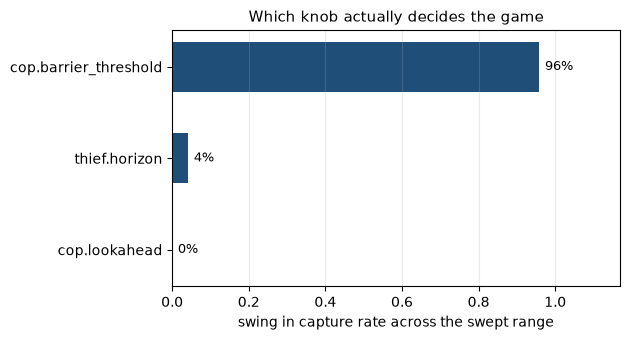

In [2]:
fig = charts.tornado(sweeps)
fig

**Reading the tornado.** Bar length is the swing in capture rate across the
knob's whole swept range. One knob moves the outcome by 96 points. The other two
move it by 4 points and 0 — and 4 points is one game in 24, comfortably inside
the confidence intervals, so it is not evidence of an effect either.

That is not a disappointing result; it is the useful one, because it says where
the remaining effort belongs. The two flat knobs are also flat for *different*
reasons, and the difference between those reasons matters more than the bars do.

## 2. The cop's sensitivity study

`barrier_threshold` is the confidence the cop requires before spending one of
its 14 barriers. `lookahead` is how many steps of the thief's own movement are
diffused into the belief before a move is scored.

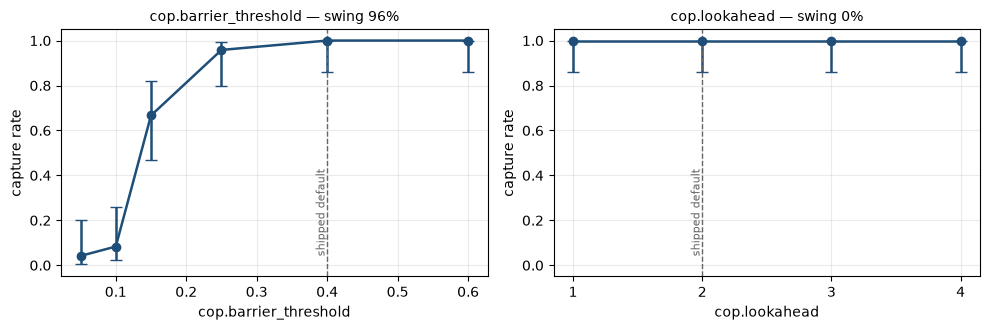

In [3]:
fig = charts.sensitivity_grid(
    {k: v for k, v in sweeps.items() if k.startswith("cop.")},
    defaults={"cop.barrier_threshold": 0.40, "cop.lookahead": 2},
)
fig

### 2.1 `barrier_threshold` — the knob that decides the match

| Threshold | Captures | Rate | 95 % CI |
|---|---|---|---|
| 0.05 | 1/24 | 4 % | 0.7–20 % |
| 0.10 | 2/24 | 8 % | 2–26 % |
| 0.15 | 16/24 | 67 % | 47–82 % |
| 0.25 | 23/24 | 96 % | 80–99 % |
| **0.40 (shipped)** | **24/24** | **100 %** | **86–100 %** |
| 0.60 | 24/24 | 100 % | 86–100 % |

A 96-point swing, and the intervals at the two ends do not come close to
overlapping — this is signal, not noise.

The mechanism is worth stating because it is counter-intuitive and it was a real
bug for weeks. **A barrier is impassable for both sides.** A cop that walls on
weak evidence does not trap the thief; it fences *itself* away from the thief it
is chasing. Spending barriers cheaply reads like aggression and behaves like
self-harm. We shipped 0.15 for most of the project, which cost roughly a third
of our games, and the sweep is what found it.

0.60 performs identically to 0.40. We shipped the lower of the two so the cop
still has the option available in the less decisive positions a stronger
opponent would create — 0.60 wins the same games here while being strictly more
reluctant, and there is no evidence to prefer the extra reluctance.

### 2.2 `lookahead` — a genuine null result

Depths 1, 2, 3 and 4 do not merely produce the same capture rate. They produce
**byte-identical games**: the same 24 outcomes and the same step count in every
one of them. That is the signature of a knob that never reaches a decision, so
the first thing to check is whether it is wired up at all.

It is. `_diffuse` demonstrably changes the belief field with depth — 5 cells at
depth 1, 33 at depth 4. The knob propagates; the *decision* is invariant, and
the reason is a property of the kernel:

$$
\tilde b_d(c) = \sum_{c'} K^d(c \mid c')\, b(c')
\qquad
K(c \mid c') = \frac{1}{|\mathcal{N}(c')|}\;\text{ for } c \in \mathcal{N}(c')
$$

$K$ is **isotropic** — it spreads probability equally in every legal direction,
because a thief whose heading we have not inferred is equally likely to go any
way. Diffusing an isotropic kernel around the believed cells shifts the expected
distance of every candidate move by nearly the same amount, so the *ranking* of
the moves, and therefore $\arg\min$, survives unchanged:

$$
a^\star = \arg\min_{a \in \mathcal{A}} \Big[ w_d \sum_c \tilde b_d(c)\,\lVert L(a) - c \rVert_1 \;-\; w_f \sum_c \tilde b_d(c)\, \mathbb{1}\big[\lVert L(a)-c \rVert_1 \le 1\big]\,(4 - r(c)) \Big]
$$

Depth would start to matter the moment the kernel became **anisotropic** —
biased by the thief's last inferred heading, so that diffusion predicts where
they are *going* rather than merely how far they could have got. That is the
single most promising strategy change this analysis identifies, and §7 records
it as future work rather than something we shipped untested.

## 3. The thief's sensitivity study, and what it exposes

`horizon` is how many steps ahead the thief protects its escape routes. Sweeping
it against the greedy baseline was uninformative: the thief survives 100 % of
games at *every* setting, which measures the opponent rather than the knob. The
sweep therefore runs the thief against **our own cop**, the strongest opponent
we have.

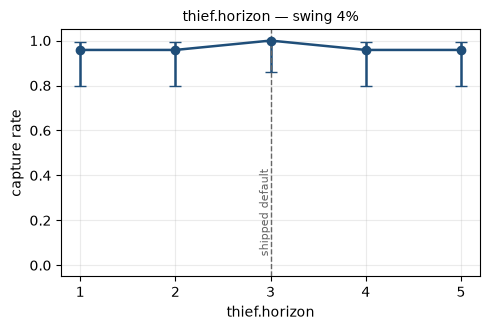

In [4]:
fig = charts.sensitivity_grid(
    {k: v for k, v in sweeps.items() if k.startswith("thief.")},
    defaults={"thief.horizon": 3},
)
fig

### 3.1 Within noise — and the uncomfortable finding underneath

Against our own cop the thief is caught in 23 or 24 of 24 games at every horizon.
The one-game differences are far inside the Wilson intervals; nothing here
justifies a claim that any horizon beats another, and the notebook does not make
one.

The result that *does* matter is the level rather than the slope:

> **Our thief survives 60/60 games against the greedy cop and roughly 1/24
> against our own cop.**

Our thief's headline survival number is a statement about the opponent it was
measured against. A league opponent whose cop is as good as ours should be
expected to catch it. This is the largest known competitive risk in the project
and it is recorded as such in `docs/OPEN_ITEMS.md` rather than being left to be
discovered by the league table.

### 3.2 Hint policy

The hint is free language sent to the opponent each turn (rules 26–27), and it
may be a bluff. Its A/B is a different kind of question from the two above: the
outcome depends on how the *opponent* reads the hint, so a self-play sweep
measures our own parser rather than the policy. Two things are measurable
locally and are asserted in the test suite rather than plotted here:

* every emitted hint passes the same guard, so no unvetted text reaches the wire
  (`tests/unit/test_llm/test_hint_guard.py`);
* an incoming hint is fenced and sanitised before it reaches a model, and a
  suspicious one has its extracted confidence discounted rather than trusted
  (`tests/unit/test_llm/test_injection_guard.py`).

The honest position is that the *persuasive* value of our bluffs is unmeasured
until we play opponents who are not us.

## 4. Against the baseline — held-out games

Seed 11, never used during tuning. 60 games per matchup, played through the full
match machinery.

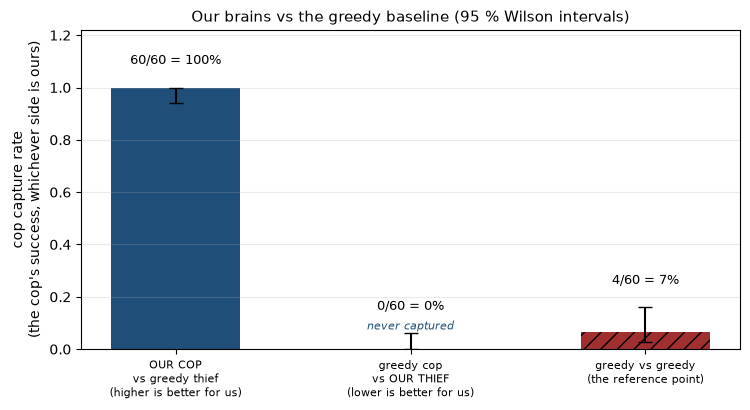

In [5]:
fig = charts.comparison(baselines, labels={
    "ours_cop_vs_greedy_thief": "OUR COP\nvs greedy thief\n(higher is better for us)",
    "ours_thief_vs_greedy_cop": "greedy cop\nvs OUR THIEF\n(lower is better for us)",
    "greedy_vs_greedy": "greedy vs greedy\n(the reference point)",
})
fig

In [6]:
for name, point in baselines.items():
    print(f"{name:28} {point.successes:3}/{point.played:3} = {point.rate:6.1%}  "
          f"95% CI [{point.ci[0]:.3f}, {point.ci[1]:.3f}]")

ours_cop_vs_greedy_thief      60/ 60 = 100.0%  95% CI [0.940, 1.000]
ours_thief_vs_greedy_cop       0/ 60 =   0.0%  95% CI [0.000, 0.060]
greedy_vs_greedy               4/ 60 =   6.7%  95% CI [0.026, 0.159]


Read as three claims:

1. **Our cop captures 100 % (CI 94–100 %) where the greedy cop captures 6.7 %
   (CI 2.6–16 %).** The intervals are disjoint by a wide margin. The pursuit
   policy is the project's strongest measured result.
2. **Our thief is never caught by the greedy cop** (0/60; the capture rate's
   interval is 0–6 %). §3.1 is the caveat that belongs beside this number.
3. **Zero disagreements and zero audit failures across all 180 games.** This is
   a correctness result rather than a strategy one, and arguably the more
   important of the two: under rules 33–35 two peers that report different
   endings void the game *for both*. Three separate defects of exactly that
   shape — a captured thief that never answered, a survival nobody announced,
   and a barrier capture only the cop noticed — were found by this harness while
   every unit test stayed green.

## 5. The formal model

**Decentralised POMDP.** Two agents, neither of which observes the state, each
choosing actions from private information. Formally
$\langle I, S, \{A_i\}, T, R, \{\Omega_i\}, O, h \rangle$ with $|I| = 2$,
$S = \{(x_{\text{cop}}, x_{\text{thief}}, B)\}$ over cells and the barrier set,
and horizon $h = 35$. The general problem is NEXP-complete [1], which is the
formal reason this project *approximates* rather than solves: we do not compute
a joint policy, we maintain a belief and act greedily against it.

**Belief update.** A Bayes filter over the thief's cell, with the scent field as
the observation:

$$
b_t(c) \;=\; \eta \; \underbrace{O(z_t \mid c)}_{\text{scent, unfakeable}} \; \sum_{c'} \underbrace{T(c \mid c')}_{\text{legal moves}} \, b_{t-1}(c')
\qquad \eta = \Big[\textstyle\sum_c \cdots\Big]^{-1}
$$

**Scent decay.** The thief leaves a trace that decays geometrically, so recency
is encoded in magnitude:

$$
\sigma_t(c) \;=\; \gamma\,\sigma_{t-1}(c) \;+\; \mathbb{1}\big[x_t = c\big],
\qquad \gamma \in (0,1)
\qquad\Longleftrightarrow\qquad
\sigma_t(c) = \sum_{k \le t} \gamma^{\,t-k}\,\mathbb{1}\big[x_k = c\big]
$$

This is the stigmergic channel [6, 7]: the thief cannot lie through it, which is
exactly why the hint channel — where it *can* lie — is weighted so much less.

**Cop objective.** One-step expectimax against the diffused belief, with a
freedom-denial term that pulls the cop toward cornering rather than orbiting:

$$
a^\star = \arg\min_{a} \; \mathbb{E}_{c \sim \tilde b}\big[\lVert L(a) - c \rVert_1\big] \;-\; w_f \, \mathbb{E}_{c \sim \tilde b}\big[\mathbb{1}[\text{adjacent}]\,(4 - r(c))\big]
$$

where $r(c)$ is the number of escape routes from $c$. Standing beside a cell with
four exits is worth little; standing beside a cornered one is nearly a capture.

**Thief objective.** Maximise the expected survival time, truncated at the
horizon — surviving to step 35 and surviving to step 100 score identically, so
there is no value in prolonging beyond it:

$$
\pi^\star = \arg\max_{\pi} \; \mathbb{E}_{\pi}\big[\min(T_{\text{capture}},\, H)\big], \qquad H = 35
$$

**Commit–reveal.** Each turn's payload is sealed before the opponent moves and
opened afterwards, so neither side can adapt a move to information it should not
yet have [8, 9]:

$$
\mathrm{commit} = \mathrm{SHA256}\big(\mathrm{canon}(p) \;\Vert\; \texttt{"|"} \;\Vert\; \nu\big)
$$

with $\mathrm{canon}$ a canonical JSON encoding (sorted keys, no incidental
whitespace) so that two peers hash identical bytes, and $\nu$ a per-turn nonce
kept secret until reveal (rule 18). Binding comes from collision resistance and
hiding from the nonce; a mismatch at reveal voids the game for the party whose
records fail to re-hash (rule 19).

## 6. What a series costs

In [7]:
rows = costs.cost_rows(tokens)
print(costs.as_markdown(rows, shipped=2))
print()
print(costs.headline(tokens, shipped=2))

| Hint cadence | Model calls | Input tokens | Output tokens | Total | USD | Share of 200k cap | Saving vs all-LLM |
|---|---:|---:|---:|---:|---:|---:|---:|
| every turn | 71 | 7,326 | 1,183 | 8,509 | $0.0132 | 4.3% | 0% |
| every 2 turns **(shipped)** | 38 | 3,928 | 649 | 4,577 | $0.0072 | 2.3% | 46% |
| every 3 turns | 27 | 2,798 | 477 | 3,275 | $0.0052 | 1.6% | 62% |

A six-game series costs 4,577 tokens ($0.0072) at the shipped cadence — 2.3% of the agreed 200,000 cap, or 6.8% in the worst case where every game runs the full 35-step horizon. Skipping the model on off-cycle turns saves 46% against calling it every turn.


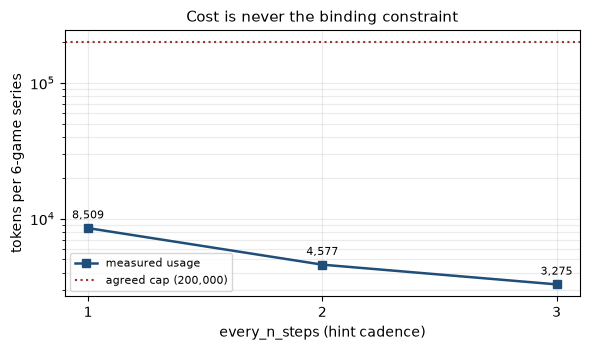

In [8]:
fig = charts.cost_curve(tokens["measurements"], tokens["series_token_budget"])
fig

### 6.1 Cost optimisation, and why it is not the point

Three mechanisms reduce consumption, and all three were chosen for reasons other
than money:

**Hint cadence (`every_n_steps = 2`)** — the model is skipped on off-cycle turns
and the template line is used instead. Measured saving: **46 %** against calling
the model every turn (8,509 → 4,577 tokens per series). This is a *quality*
setting: an opponent does not need fresh prose every step to be misled, and the
saving is a side effect.

**Per-purpose routing.** The configuration reserves a stronger model for
negotiation than for hints. Measured usage shows this is currently inert:
**100 % of runtime model calls are hint-purpose**, because `docs/PRD_negotiation.md`
deliberately rejected free-form LLM negotiation — unbounded and unverifiable,
and rule 26 governs hints, not contracts. The `negotiation_model` key therefore
configures nothing today, which is recorded as a documentation defect rather
than quietly presented as a cost optimisation.

**The template floor.** A provider outage costs zero tokens and loses zero
games: the chain falls through to a local template and play continues. This is
an availability mechanism whose cost saving is incidental.

### 6.2 The conclusion the numbers support

A six-game series costs about **2.3 % of the agreed 200,000-token cap**, and
**6.8 %** in the worst case where all six games run the full 35-step horizon
(the measured series ends sooner because our cop wins quickly). There is more
than an order of magnitude of headroom.

**Cost is therefore not a constraint we should be optimising against, and the
budget machinery exists to honour a signed term and to catch a runaway loop —
not to make the agent play worse to save fractions of a cent.** The 70 % warn
and 90 % degrade thresholds in `TokenMeter` protect the *agreement*; at measured
consumption they never bind.

## 7. Findings, limitations and future work

**Findings**

1. `barrier_threshold` is the only tunable that decides games: 4 % → 100 %
   capture across its range. Mis-set at 0.15 it cost roughly a third of our
   games for most of the project.
2. Search depth is inert under an isotropic diffusion kernel — a null result
   with a proof sketch (§2.2) rather than an absence of evidence.
3. Our cop is decisively better than the greedy baseline on held-out games
   (100 % vs 6.7 %, disjoint intervals).
4. Our thief's survival is opponent-dependent and collapses against a strong
   cop. This is the project's biggest competitive risk.
5. 180 games produced zero peer disagreements and zero audit failures.
6. Token cost is roughly 2 % of the agreed cap and is not a binding constraint.

**Limitations — what these numbers do not support**

* *Every opponent here is us or a greedy baseline.* Self-play measures internal
  consistency. It cannot measure how our bluffs read to a team that did not
  write our parser, and §3.2's hint policy is unmeasured for exactly this reason.
* *OAT sweeps cannot see interactions.* `barrier_threshold` was swept with
  `lookahead` fixed. A depth that mattered under an anisotropic kernel could
  well move the best threshold.
* *24 games per sweep point* is enough to separate 4 % from 100 % and nowhere
  near enough to separate 96 % from 100 %.
* *Token counts use a proxy tokenizer.* Volumes are real; the conversion is
  approximate and the prices are the vendor's.

**Future work, in the order the evidence prioritises it**

1. **Anisotropic diffusion** biased by the thief's inferred heading, which would
   give `lookahead` something to do (§2.2).
2. **A stronger thief**, since ours loses to a competent cop (§3.1).
3. **Interaction sweeps** over the two cop knobs jointly, once (1) makes the
   second one live.

## 8. References

1. Bernstein, D. S., Givan, R., Immerman, N., & Zilberstein, S. (2002). The
   complexity of decentralized control of Markov decision processes.
   *Mathematics of Operations Research*, 27(4), 819–840. — the NEXP-completeness
   result that justifies approximating rather than solving the joint policy.
2. Oliehoek, F. A., & Amato, C. (2016). *A Concise Introduction to Decentralized
   POMDPs*. Springer. — the Dec-POMDP formalism used in §5.
3. Kaelbling, L. P., Littman, M. L., & Cassandra, A. R. (1998). Planning and
   acting in partially observable stochastic domains. *Artificial Intelligence*,
   101(1–2), 99–134. — the belief-filter formulation.
4. Nowakowski, R., & Winkler, P. (1983). Vertex-to-vertex pursuit in a graph.
   *Discrete Mathematics*, 43(2–3), 235–239. — cop-win graph characterisation.
5. Bonato, A., & Nowakowski, R. J. (2011). *The Game of Cops and Robbers on
   Graphs*. American Mathematical Society. — the pursuit game this project is an
   instance of, including why barriers change the cop number.
6. Grassé, P.-P. (1959). La reconstruction du nid et les coordinations
   interindividuelles chez *Bellicositermes natalensis* et *Cubitermes* sp.
   *Insectes Sociaux*, 6, 41–80. — the original statement of stigmergy, the
   mechanism the scent field implements.
7. Dorigo, M., Maniezzo, V., & Colorni, A. (1996). Ant System: optimization by a
   colony of cooperating agents. *IEEE Transactions on Systems, Man, and
   Cybernetics, Part B*, 26(1), 29–41. — geometric pheromone decay, the direct
   analogue of our scent law.
8. Blum, M. (1983). Coin flipping by telephone: a protocol for solving
   impossible problems. *ACM SIGACT News*, 15(1), 23–27. — the commitment
   problem our commit–reveal solves.
9. Naor, M. (1991). Bit commitment using pseudorandomness. *Journal of
   Cryptology*, 4(2), 151–158. — binding and hiding, the two properties §5 relies on.
10. Wilson, E. B. (1927). Probable inference, the law of succession, and
    statistical inference. *Journal of the American Statistical Association*,
    22(158), 209–212. — the interval used throughout.
11. Isaacs, R. (1965). *Differential Games*. Wiley. — the pursuit–evasion
    tradition these objectives descend from.
12. Russell, S., & Norvig, P. (2020). *Artificial Intelligence: A Modern
    Approach* (4th ed.). Pearson. — expectimax over chance nodes, §5's cop objective.